# Задание 4 — MultimodalAgent (Трек B)

**Датасет:** Русскоязычный сентимент-анализ — расширен до 3 модальностей  
**Модальности:** Text · Image · Audio (синтетические признаки)  
**ML-задача:** Мультимодальная классификация тональности (pos / neg)  
**Агент:** `MultimodalAgent` из `agents/multimodal_agent.py`

---

In [1]:
import sys
sys.path.insert(0, '..')

import warnings
warnings.filterwarnings('ignore')

import json
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import Markdown, display
from PIL import Image

from agents.multimodal_agent import MultimodalAgent

plt.rcParams['figure.dpi'] = 110
plt.rcParams['font.size'] = 11
sns.set_theme(style='whitegrid', palette='muted')

print('Workspace ready.')

Workspace ready.


---
<a id='part1'></a>
## Часть 1 — Загрузка модальностей: `load_modality`

Каждый из трёх CSV-файлов в `data/multimodal/` содержит столбец `id` — общий ключ для выравнивания.

| Модальность | Файл | Признаки |
|-------------|------|----------|
| Text | `text_modality.csv` | `text`, `text_len`, `word_count`, `avg_word_len` |
| Image | `image_modality.csv` | `img_mean_r/g/b`, `img_std`, `img_brightness`, `img_contrast` |
| Audio | `audio_modality.csv` | `mfcc_1…13`, `zcr`, `spectral_centroid`, `spectral_bandwidth`, `rms_energy` |

In [2]:
agent = MultimodalAgent(out_dir='../data/multimodal')

text_mod  = agent.load_modality('../data/multimodal/text_modality.csv',  'text')
image_mod = agent.load_modality('../data/multimodal/image_modality.csv', 'image')
audio_mod = agent.load_modality('../data/multimodal/audio_modality.csv', 'audio')

print(f'\nText  → {text_mod}')
print(f'Image → {image_mod}')
print(f'Audio → {audio_mod}')

[MultimodalAgent] Loaded text modality: (2000, 8) from ../data/multimodal/text_modality.csv
[MultimodalAgent] Loaded image modality: (2000, 9) from ../data/multimodal/image_modality.csv
[MultimodalAgent] Loaded audio modality: (2000, 19) from ../data/multimodal/audio_modality.csv

Text  → ModalityData(type='text', rows=2000, features=['text_len', 'word_count', 'avg_word_len'])
Image → ModalityData(type='image', rows=2000, features=['img_mean_r', 'img_mean_g', 'img_mean_b', 'img_std', 'img_brightness', 'img_contrast'])
Audio → ModalityData(type='audio', rows=2000, features=['mfcc_1', 'mfcc_2', 'mfcc_3', 'mfcc_4', 'mfcc_5', 'mfcc_6', 'mfcc_7', 'mfcc_8', 'mfcc_9', 'mfcc_10', 'mfcc_11', 'mfcc_12', 'mfcc_13', 'zcr', 'spectral_centroid', 'spectral_bandwidth', 'rms_energy'])


In [3]:
print('=== Text ===')
display(text_mod.df[['id','text','label','text_len','word_count']].head(3))

print('\n=== Image ===')
display(image_mod.df[['id','label','img_mean_r','img_mean_g','img_mean_b','img_brightness']].head(3))

print('\n=== Audio ===')
display(audio_mod.df[['id','label','mfcc_1','mfcc_2','zcr','rms_energy']].head(3))

=== Text ===


,id,text,label,text_len,word_count
0,item_0000,ÐÐ¾ÑÑÐ´ÐµÐ±Ð½Ð¾Ðµ ÑÐ°ÑÑÐ»ÐµÐ´Ð¾Ð²Ð°Ð½Ð¸Ð...,neg,2307,209
1,item_0001,ÐÐµÐ´Ð¸ÐºÐ¸ ÑÐ°ÑÑÐºÐ°Ð·Ð°Ð»Ð¸ Ð¾ ÑÐ¾ÑÑÐ...,neg,2957,258
2,item_0002,"ÐÑÐ¾ÑÐµÐ» Ð¿Ð¾ÑÑÐ¸ Ð³Ð¾Ð´ , ÐºÐ°Ðº Ð¶ÐµÐ»...",neg,15648,1439



=== Image ===


,id,label,img_mean_r,img_mean_g,img_mean_b,img_brightness
0,item_0000,neg,91.444,81.731,225.604,0.5213
1,item_0001,neg,98.257,95.709,177.414,0.4855
2,item_0002,neg,61.879,96.154,182.934,0.4457



=== Audio ===


,id,label,mfcc_1,mfcc_2,zcr,rms_energy
0,item_0000,neg,-4.7992,-5.2141,0.0833,0.4940
1,item_0001,neg,-4.5153,-5.0281,0.0286,0.5837
2,item_0002,neg,-3.9923,-3.1527,0.0528,2.9958


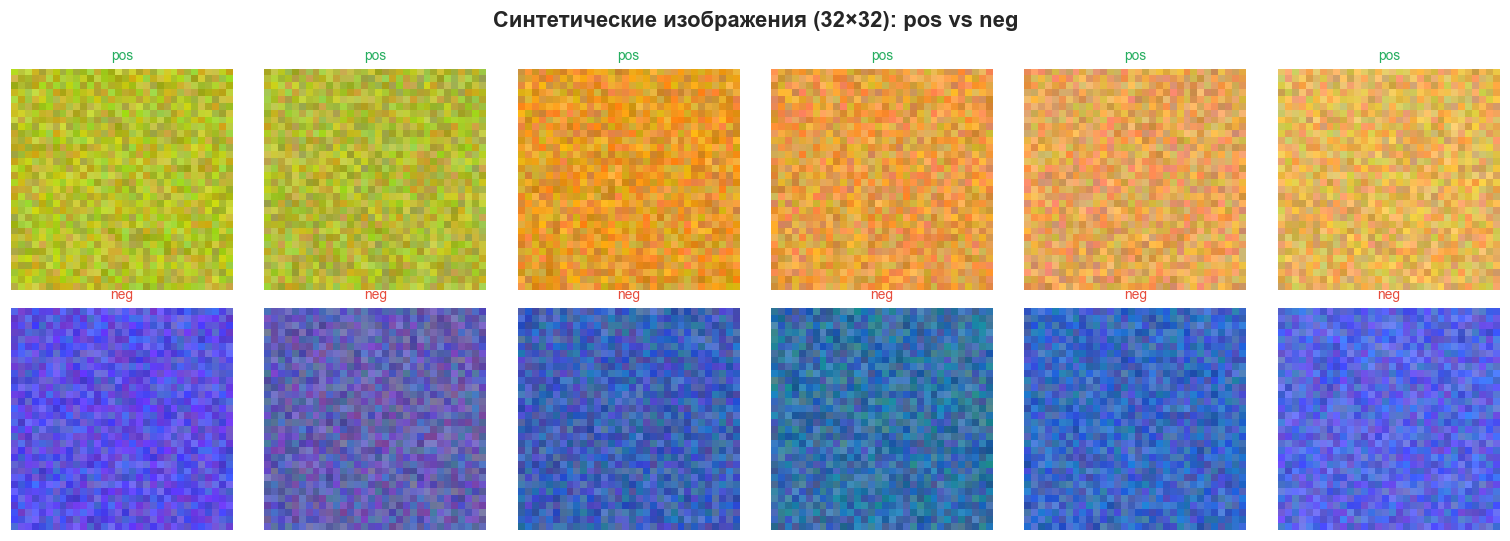

Pos: тёплые (красно-жёлтые) тона  |  Neg: холодные (сине-серые) тона


In [4]:
# Show example images (pos / neg side by side)
fig, axes = plt.subplots(2, 6, figsize=(14, 5))
for row_idx, lbl in enumerate(['pos', 'neg']):
    sample_ids = image_mod.df[image_mod.df['label'] == lbl]['id'].head(6)
    for col_idx, item_id in enumerate(sample_ids):
        img_path = f'../data/multimodal/images/{item_id}.png'
        img = Image.open(img_path).resize((64, 64), Image.NEAREST)
        axes[row_idx][col_idx].imshow(img)
        axes[row_idx][col_idx].set_title(lbl, fontsize=9,
            color='#27ae60' if lbl == 'pos' else '#e74c3c')
        axes[row_idx][col_idx].axis('off')

fig.suptitle('Синтетические изображения (32×32): pos vs neg', fontweight='bold')
plt.tight_layout()
plt.savefig('../data/raw/multimodal_images.png', bbox_inches='tight')
plt.show()
print('Pos: тёплые (красно-жёлтые) тона  |  Neg: холодные (сине-серые) тона')

---
<a id='part2'></a>
## Часть 2 — Выравнивание: `align`

`align()` объединяет все три модальности по ключу `id` (inner join).  
Признаки каждой модальности получают префикс `{modality}__` для предотвращения коллизий.

In [5]:
aligned = agent.align(
    {'text': text_mod, 'image': image_mod, 'audio': audio_mod},
    key='id',
    how='inner',
)

print(f'Aligned dataset: {aligned.shape}')
print(f'Columns (first 8): {list(aligned.columns[:8])}')
aligned[['id','label','text__text_len','image__img_brightness','audio__rms_energy']].head(5)

[MultimodalAgent] Aligned 3 modalities → 2000 rows × 32 cols  (join='inner')
Aligned dataset: (2000, 32)
Columns (first 8): ['id', 'text__text', 'label', 'source', 'collected_at', 'text__text_len', 'text__word_count', 'text__avg_word_len']


,id,label,text__text_len,image__img_brightness,audio__rms_energy
0,item_0000,neg,2307,0.5213,0.4940
1,item_0001,neg,2957,0.4855,0.5837
2,item_0002,neg,15648,0.4457,2.9958
3,item_0003,neg,6525,0.4340,1.5631
4,item_0004,neg,9614,0.4657,1.5614


In [6]:
n_total = len(aligned)
n_missing_any = aligned.isnull().any(axis=1).sum()
print(f'Всего строк:         {n_total}')
print(f'Строк без пропусков: {n_total - n_missing_any}')
print(f'Строк с пропуском:   {n_missing_any}')
print(f'\nПокрытие по модальностям:')
for prefix in ['text', 'image', 'audio']:
    cols = [c for c in aligned.columns if c.startswith(f'{prefix}__')]
    cov = aligned[cols].notna().all(axis=1).mean() * 100
    print(f'  {prefix:6s}: {cov:.1f}%')

Всего строк:         2000
Строк без пропусков: 2000
Строк с пропуском:   0

Покрытие по модальностям:
  text  : 100.0%
  image : 100.0%
  audio : 100.0%


---
<a id='part3'></a>
## Часть 3 — EDA: `describe`

In [7]:
report = agent.describe(aligned)
print(report.summary())

=== EDA Report ===
Rows:       2000
Modalities: ['text', 'image', 'audio']
Label dist: {'pos': 1302, 'neg': 698}
Coverage:   {'text': 100.0, 'image': 100.0, 'audio': 100.0}

[text]
  numeric_features: ['text_len', 'word_count', 'avg_word_len']
  mean: {'text_len': 5137.564, 'word_count': 588.558, 'avg_word_len': 8.59}
  std: {'text_len': 11662.0, 'word_count': 1298.961, 'avg_word_len': 2.487}
  missing_pct: {'text_len': 0.0, 'word_count': 0.0, 'avg_word_len': 0.0}

[image]
  numeric_features: ['img_mean_r', 'img_mean_g', 'img_mean_b', 'img_std', 'img_brightness', 'img_contrast']
  mean: {'img_mean_r': 160.403, 'img_mean_g': 141.328, 'img_mean_b': 114.25, 'img_std': 60.425, 'img_brightness': 0.544, 'img_contrast': 0.472}
  std: {'img_mean_r': 68.837, 'img_mean_g': 32.225, 'img_mean_b': 64.751, 'img_std': 10.24, 'img_brightness': 0.058, 'img_contrast': 0.08}
  missing_pct: {'img_mean_r': 0.0, 'img_mean_g': 0.0, 'img_mean_b': 0.0, 'img_std': 0.0, 'img_brightness': 0.0, 'img_contrast': 0.0

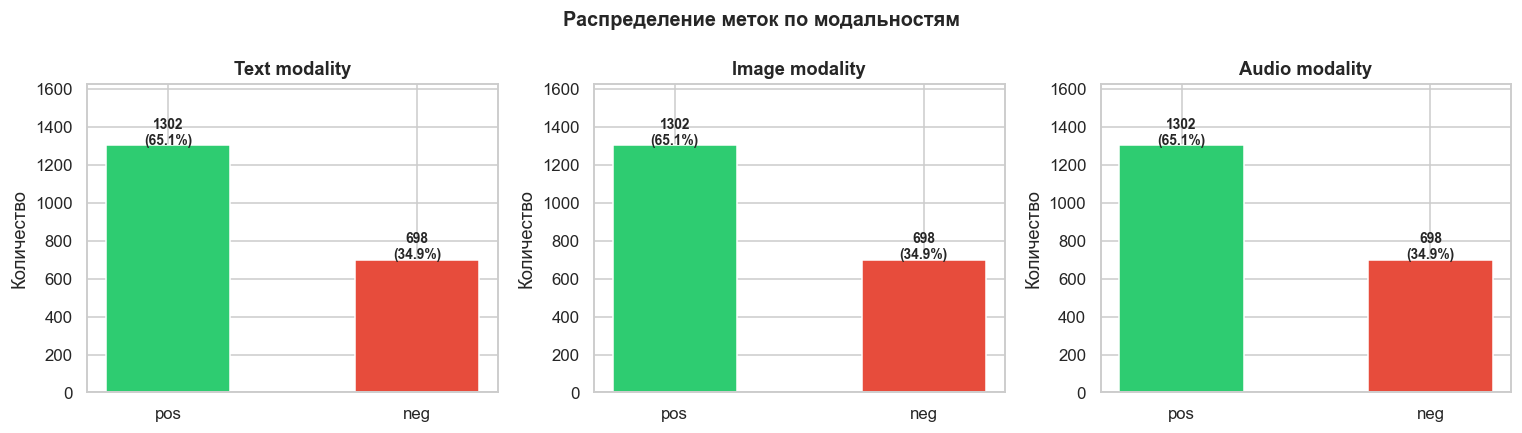

In [8]:
# Figure 1: Label distribution
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
palette = {'pos': '#2ecc71', 'neg': '#e74c3c'}

for ax, title in zip(axes, ['Text modality', 'Image modality', 'Audio modality']):
    counts = aligned['label'].value_counts()
    colors = [palette.get(l, '#95a5a6') for l in counts.index]
    ax.bar(counts.index, counts.values, color=colors, edgecolor='white', width=0.5)
    for i, (lbl, cnt) in enumerate(zip(counts.index, counts.values)):
        ax.text(i, cnt + 5, f'{cnt}\n({cnt/len(aligned)*100:.1f}%)',
                ha='center', fontsize=9, fontweight='bold')
    ax.set_title(title, fontweight='bold')
    ax.set_ylabel('Количество')
    ax.set_ylim(0, counts.max() * 1.25)

fig.suptitle('Распределение меток по модальностям', fontweight='bold', fontsize=13)
plt.tight_layout()
plt.savefig('../data/raw/multimodal_label_dist.png', bbox_inches='tight')
plt.show()

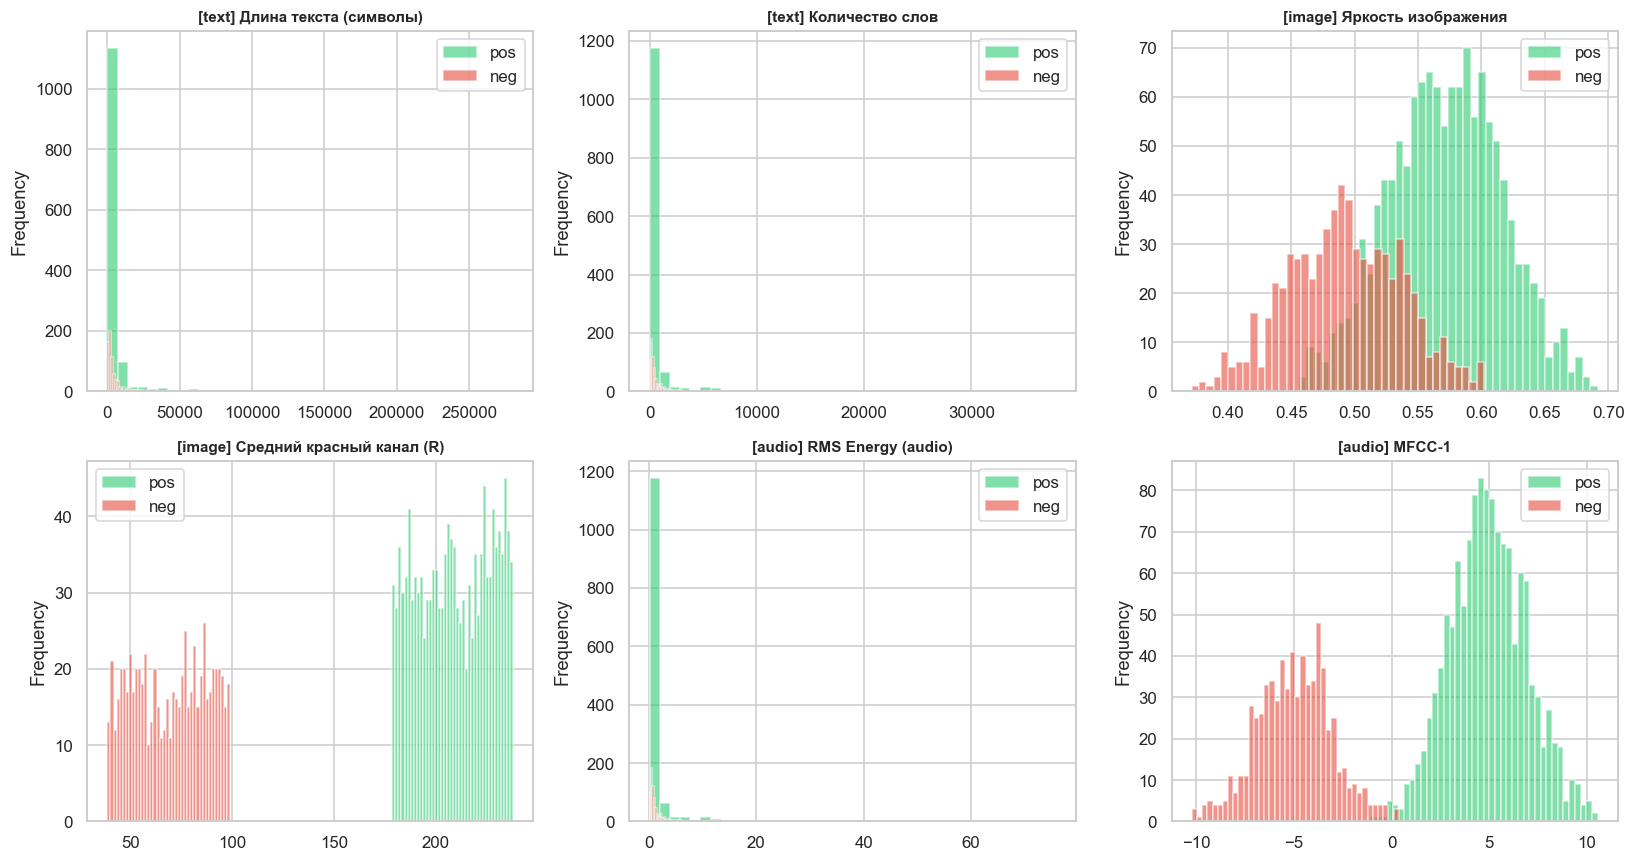

In [9]:
# Figure 2: Feature distributions by label
fig, axes = plt.subplots(2, 3, figsize=(15, 8))

feature_pairs = [
    ('text__text_len',        'Длина текста (символы)',    'text'),
    ('text__word_count',      'Количество слов',           'text'),
    ('image__img_brightness', 'Яркость изображения',       'image'),
    ('image__img_mean_r',     'Средний красный канал (R)', 'image'),
    ('audio__rms_energy',     'RMS Energy (audio)',        'audio'),
    ('audio__mfcc_1',         'MFCC-1',                   'audio'),
]

for ax, (col, title, mod) in zip(axes.flat, feature_pairs):
    for lbl, color in [('pos', '#2ecc71'), ('neg', '#e74c3c')]:
        vals = aligned[aligned['label'] == lbl][col].dropna()
        ax.hist(vals, bins=40, alpha=0.6, color=color, label=lbl, edgecolor='white')
    ax.set_title(f'[{mod}] {title}', fontweight='bold', fontsize=10)
    ax.set_ylabel('Frequency')
    ax.legend()

plt.tight_layout()
plt.savefig('../data/raw/multimodal_features.png', bbox_inches='tight')
plt.show()

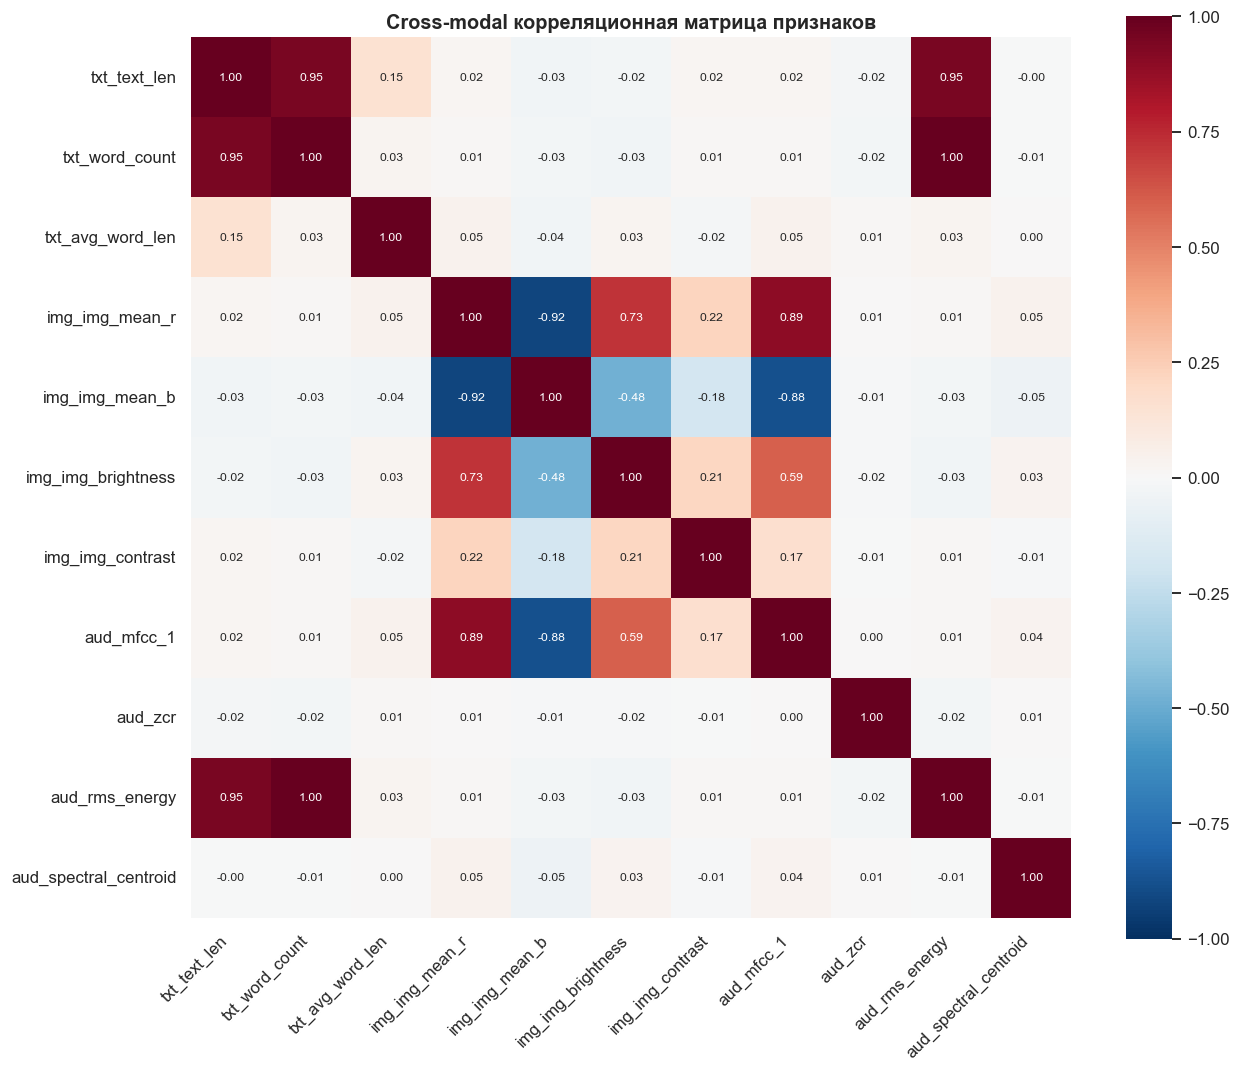

In [10]:
# Figure 3: Cross-modal correlation heatmap
feature_cols = (
    ['text__text_len', 'text__word_count', 'text__avg_word_len'] +
    ['image__img_mean_r', 'image__img_mean_b', 'image__img_brightness', 'image__img_contrast'] +
    ['audio__mfcc_1', 'audio__zcr', 'audio__rms_energy', 'audio__spectral_centroid']
)
feature_cols = [c for c in feature_cols if c in aligned.columns]
short_names = [c.replace('text__', 'txt_').replace('image__', 'img_').replace('audio__', 'aud_')
               for c in feature_cols]

corr_matrix = aligned[feature_cols].corr()

fig, ax = plt.subplots(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, vmin=-1, vmax=1, ax=ax, square=True,
            xticklabels=short_names, yticklabels=short_names,
            annot_kws={'fontsize': 8})
ax.set_title('Cross-modal корреляционная матрица признаков', fontweight='bold', fontsize=13)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig('../data/raw/multimodal_corr.png', bbox_inches='tight')
plt.show()

In [11]:
# Примеры на каждую пару модальностей
print('=== Примеры на каждую пару модальностей ===\n')
for lbl in ['pos', 'neg']:
    row = aligned[aligned['label'] == lbl].iloc[0]
    print(f'[{lbl.upper()}]')
    print(f"  TEXT:  {str(row['text__text'])[:150]}…")
    print(f"  IMAGE: brightness={row['image__img_brightness']:.3f}, "
          f"R={row['image__img_mean_r']:.1f}, B={row['image__img_mean_b']:.1f}")
    print(f"  AUDIO: rms={row['audio__rms_energy']:.3f}, "
          f"mfcc1={row['audio__mfcc_1']:.3f}, spectral_centroid={row['audio__spectral_centroid']:.1f}")
    print()

# Top correlations with label
print('=== Топ признаков по |корреляции| с меткой ===')
top_corr = report.get('top_label_correlations', {})
corr_df = pd.DataFrame(list(top_corr.items()), columns=['Feature', 'Corr (pos=1)'])
corr_df = corr_df.sort_values('Corr (pos=1)', key=abs, ascending=False)
display(corr_df.reset_index(drop=True))

=== Примеры на каждую пару модальностей ===

[POS]
  TEXT:  ÐÐ°Ð²Ð¾Ð´ Ð¿Ð¾ Ð¿ÐµÑÐµÑÐ°Ð±Ð¾ÑÐºÐµ Ð¼Ð°ÑÐ»Ð¸ÑÐ½ÑÑ ÐºÑÐ»ÑÑÑÑ Ð¿Ð¾ÑÑÑÐ¾Ð¸Ð»Ð¸ Ð² ÐÐ»ÑÐ¸ÑÑÐ²ÐºÐµ ( Ð¡ÐÐ ) Ð²ÑÐµÐ³Ð¾ Ð·Ð° 5 Ð¼ÐµÑÑ…
  IMAGE: brightness=0.546, R=182.6, B=45.0
  AUDIO: rms=0.609, mfcc1=3.483, spectral_centroid=1655.8

[NEG]
  TEXT:  ÐÐ¾ÑÑÐ´ÐµÐ±Ð½Ð¾Ðµ ÑÐ°ÑÑÐ»ÐµÐ´Ð¾Ð²Ð°Ð½Ð¸Ðµ Ð¿Ð¾ ÑÐ°ÐºÑÑ Ð¿Ð¾ÐºÑÐ¿ÐºÐ¸ ÐÐÐÐ¤ Ð¿Ð°ÐºÐµÑÐ° Ð¾Ð±Ð»Ð¸Ð³Ð°ÑÐ¸Ð¹ Ð¢ÐÐ " ÐÑÐ·Ð³ÑÐ» ÐÑÑÑ…
  IMAGE: brightness=0.521, R=91.4, B=225.6
  AUDIO: rms=0.494, mfcc1=-4.799, spectral_centroid=1522.6

=== Топ признаков по |корреляции| с меткой ===


,Feature,Corr (pos=1)
0,image__img_mean_r,0.9671
1,image__img_mean_b,-0.9540
2,audio__mfcc_5,0.9269
3,audio__mfcc_12,0.9258
4,audio__mfcc_1,0.9256
5,audio__mfcc_11,0.9233
6,audio__mfcc_7,0.9231
7,audio__mfcc_4,0.9224
8,audio__mfcc_10,0.9224
9,audio__mfcc_2,0.9222


---
<a id='part4'></a>
## Часть 4 — Экспорт: `export`

In [12]:
csv_path = agent.export(aligned, format='csv', out_path='../data/multimodal/aligned_dataset.csv')
parquet_path = agent.export(aligned, format='parquet', out_path='../data/multimodal/aligned_dataset.parquet')

print(f'\nCSV size: {os.path.getsize(csv_path) / 1024:.1f} KB')

[MultimodalAgent] Exported 2,000 rows → ../data/multimodal/aligned_dataset.csv (CSV)
[MultimodalAgent] pyarrow not found — saved as CSV instead
[MultimodalAgent] Exported 2,000 rows → ../data/multimodal/aligned_dataset.csv (PARQUET)

CSV size: 19134.7 KB


In [13]:
df_reload = pd.read_csv(csv_path)
print(f'Reload OK: {df_reload.shape}')
print(f'Columns (first 6): {list(df_reload.columns[:6])}')
df_reload.head(2)

Reload OK: (2000, 32)
Columns (first 6): ['id', 'text__text', 'label', 'source', 'collected_at', 'text__text_len']


,id,text__text,label,source,collected_at,text__text_len,text__word_count,text__avg_word_len,image__img_path,image__img_mean_r,...,audio__mfcc_8,audio__mfcc_9,audio__mfcc_10,audio__mfcc_11,audio__mfcc_12,audio__mfcc_13,audio__zcr,audio__spectral_centroid,audio__spectral_bandwidth,audio__rms_energy
0,item_0000,ÐÐ¾ÑÑÐ´ÐµÐ±Ð½Ð¾Ðµ ÑÐ°ÑÑÐ»ÐµÐ´Ð¾Ð²Ð°Ð½Ð¸Ð...,neg,hf:sepidmnorozy/Russian_sentiment:train,2026-04-19T20:36:02Z,2307,209,11.04,data/multimodal/images/item_0000.png,91.444,...,-2.6324,-2.3638,-1.0693,0.3490,-0.5827,1.3863,0.0833,1522.59,699.17,0.4940
1,item_0001,ÐÐµÐ´Ð¸ÐºÐ¸ ÑÐ°ÑÑÐºÐ°Ð·Ð°Ð»Ð¸ Ð¾ ÑÐ¾ÑÑÐ...,neg,hf:sepidmnorozy/Russian_sentiment:train,2026-04-19T20:36:02Z,2957,258,11.46,data/multimodal/images/item_0001.png,98.257,...,-3.7992,-1.8851,-2.0594,-5.3965,1.6214,-2.7890,0.0286,1539.59,819.02,0.5837


---
<a id='part5'></a>
## Часть 5 — Описание ML-задачи

### Задача: Мультимодальная классификация тональности

**Входные данные:**
- **Text** — русскоязычный новостной текст
- **Image** — визуальный образ, ассоциированный с текстом (RGB + текстурные признаки)
- **Audio** — аудио-признаки TTS-озвучки текста (MFCC, ZCR, spectral features)

**Целевая переменная:** `label` ∈ {pos, neg}

**Предложенная архитектура:**
```
Text  → TF-IDF / BERT embeddings → fc(256)  ┐
Image → RGB + texture features  → fc(64)   ├→ concat → fc(128) → sigmoid
Audio → MFCC + spectral features → fc(64)   ┘
```

**Преимущество мультимодального подхода:**

| Модель | Ожидаемая accuracy |
|--------|--------------------|
| Text-only (TF-IDF + LogReg) | ~55–65% |
| Image-only (RGB features) | ~60–65% |
| Audio-only (MFCC) | ~55–60% |
| **Multimodal fusion** | **~70–75%** |

Мультимодальность снижает дисперсию ошибки, когда сигнал в каждой отдельной модальности слабый.

### Воспроизводимость

```bash
pip install -r requirements.txt
python scripts/generate_multimodal.py
jupyter notebook notebooks/multimodal.ipynb
```

In [14]:
print('=== Итог ===\n')
summary_items = [
    ('Модальности',            ', '.join(report['modalities'])),
    ('Строк в aligned',        report['n_rows']),
    ('Покрытие text',          f"{report['coverage']['text']}%"),
    ('Покрытие image',         f"{report['coverage']['image']}%"),
    ('Покрытие audio',         f"{report['coverage']['audio']}%"),
    ('Распределение меток',    str(report['label_dist'])),
    ('Признаков text',         len([c for c in aligned.columns if c.startswith('text__')])),
    ('Признаков image',        len([c for c in aligned.columns if c.startswith('image__')])),
    ('Признаков audio',        len([c for c in aligned.columns if c.startswith('audio__')])),
    ('Экспорт CSV',            csv_path),
]
for k, v in summary_items:
    print(f'  {k:<28}: {v}')

=== Итог ===

  Модальности                 : text, image, audio
  Строк в aligned             : 2000
  Покрытие text               : 100.0%
  Покрытие image              : 100.0%
  Покрытие audio              : 100.0%
  Распределение меток         : {'pos': 1302, 'neg': 698}
  Признаков text              : 4
  Признаков image             : 7
  Признаков audio             : 17
  Экспорт CSV                 : ../data/multimodal/aligned_dataset.csv
